### Análisis y preprocesamiento de los datos 

In [582]:
# importaciones
import pandas as pd
import matplotlib.pyplot as plt

In [583]:
features_df = pd.read_csv("../data/datasets/9694_ECG_features.csv")
metadata_df = pd.read_csv("../data/datasets/ecg_records_metadata.csv")

In [584]:
features_df.head()

,ECG_ID,PR_interval,P_duration,P_amplitude,R_amplitude,S_depth,T_amplitude,T_wave_duration,T_area,T_asymmetry,QRS_duration,QT_interval,HR,RR_mean,RR_std
0,A00002,210.0,108.0,-0.014992,0.952173,-0.054122,0.061929,167.0,0.002389,1.406893,239.0,464.0,70.947790,845.692308,27.070804
1,A00003,208.0,106.0,0.157542,0.426371,-0.102212,0.057930,156.0,0.002266,0.456529,134.0,349.0,77.922078,770.000000,14.587666
2,A00006,206.0,120.0,0.048749,0.516500,-0.078645,0.132256,136.0,0.008305,0.837841,202.0,449.0,62.893082,959.333333,20.000000
3,A00008,190.0,116.0,0.060305,0.801763,-0.084734,0.192595,160.0,0.016154,1.085002,166.0,446.0,65.503395,913.555556,61.483713
4,A00009,160.0,100.0,0.068575,0.485058,-0.136107,0.142747,124.0,0.008860,0.784738,182.0,386.0,92.828540,646.352941,9.899145


In [585]:
metadata_df.head()

,ECG_ID,Age,AHA_Code,Patient_ID,Sex,N,Date;
0,A00002,32,1,S00002,M,6000,2019-09-03;
1,A00003,63,1,S00003,M,6500,2020-07-16;
2,A00006,46,1,S00006,F,5000,2019-08-31;
3,A00008,32,1,S00008,M,5000,2019-10-02;
4,A00009,48,1,S00009,F,6000,2019-08-20;


In [586]:
# Merge datasets
merged_df = pd.merge(features_df, metadata_df.loc[:, ['ECG_ID','Sex']], on='ECG_ID')

In [587]:
merged_df.head()

,ECG_ID,PR_interval,P_duration,P_amplitude,R_amplitude,S_depth,T_amplitude,T_wave_duration,T_area,T_asymmetry,QRS_duration,QT_interval,HR,RR_mean,RR_std,Sex
0,A00002,210.0,108.0,-0.014992,0.952173,-0.054122,0.061929,167.0,0.002389,1.406893,239.0,464.0,70.947790,845.692308,27.070804,M
1,A00003,208.0,106.0,0.157542,0.426371,-0.102212,0.057930,156.0,0.002266,0.456529,134.0,349.0,77.922078,770.000000,14.587666,M
2,A00006,206.0,120.0,0.048749,0.516500,-0.078645,0.132256,136.0,0.008305,0.837841,202.0,449.0,62.893082,959.333333,20.000000,F
3,A00008,190.0,116.0,0.060305,0.801763,-0.084734,0.192595,160.0,0.016154,1.085002,166.0,446.0,65.503395,913.555556,61.483713,M
4,A00009,160.0,100.0,0.068575,0.485058,-0.136107,0.142747,124.0,0.008860,0.784738,182.0,386.0,92.828540,646.352941,9.899145,F


In [588]:
# X and y split
features_df = merged_df.iloc[:, :-1]
y_series = merged_df.iloc[:, -1]

In [589]:
# Split test and train sets
from sklearn.model_selection import train_test_split

del features_df['ECG_ID']
X_train, X_test, y_train, y_test = train_test_split(features_df, y_series, test_size=0.2, random_state=42)

In [590]:
X_train.head()

,PR_interval,P_duration,P_amplitude,R_amplitude,S_depth,T_amplitude,T_wave_duration,T_area,T_asymmetry,QRS_duration,QT_interval,HR,RR_mean,RR_std
1559,176.0,100.0,0.057812,0.261870,-0.313418,0.166123,146.0,0.014479,1.062566,180.0,441.0,74.711343,803.090909,32.320707
2935,184.0,100.0,0.127298,0.410330,-0.126842,0.067104,113.0,0.003501,0.684114,181.0,423.0,92.613010,647.857143,8.830605
4387,178.0,100.0,0.099572,0.439232,-0.155431,0.180210,132.0,0.012901,0.975235,185.0,438.0,67.478660,889.230769,4.994672
9534,188.0,112.0,0.008048,0.547237,-0.182236,0.326252,134.0,0.026398,1.335559,174.0,426.0,65.144270,911.600000,27.022953
2291,212.0,126.0,0.042938,0.780700,-0.089663,0.103077,128.0,0.006233,0.992410,114.0,358.0,68.221973,874.800000,28.400000


In [591]:
X_train_df = X_train.copy()
X_test_df = X_train.copy()

### Data wrangling

In [592]:
# Clean Nan
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

data_clean = X_train.copy()

data_clean.iloc[:, 1:] = imputer.fit_transform(X_train.iloc[:, 1:])
data_clean.shape

(7755, 14)

In [593]:
data_clean.columns

Index(['PR_interval', 'P_duration', 'P_amplitude', 'R_amplitude', 'S_depth',
       'T_amplitude', 'T_wave_duration', 'T_area', 'T_asymmetry',
       'QRS_duration', 'QT_interval', 'HR', 'RR_mean', 'RR_std'],
      dtype='object')

### Aplicar Escalado a rasgos

In [594]:
from sklearn.preprocessing import StandardScaler, RobustScaler

In [595]:
# Escalado en métrica de duración e intervalos

std_features = data_clean.loc[: ,['PR_interval', 'P_duration', 'T_wave_duration', 'QRS_duration', 'QT_interval', 'RR_mean', 'HR']]
std_features.head()

,PR_interval,P_duration,T_wave_duration,QRS_duration,QT_interval,RR_mean,HR
1559,176.0,100.0,146.0,180.0,441.0,803.090909,74.711343
2935,184.0,100.0,113.0,181.0,423.0,647.857143,92.613010
4387,178.0,100.0,132.0,185.0,438.0,889.230769,67.478660
9534,188.0,112.0,134.0,174.0,426.0,911.600000,65.144270
2291,212.0,126.0,128.0,114.0,358.0,874.800000,68.221973


In [596]:
std_features.describe()

,PR_interval,P_duration,T_wave_duration,QRS_duration,QT_interval,RR_mean,HR
count,7755.000000,7755.000000,7755.000000,7755.000000,7755.000000,7755.000000,7755.000000
mean,195.887814,102.990716,135.962605,168.758736,412.318246,817.143308,74.439140
std,19.543838,18.452133,25.554842,50.963942,52.913842,95.883318,9.054265
min,122.000000,31.000000,36.000000,78.000000,170.000000,590.600000,55.388876
25%,182.000000,96.000000,128.000000,131.000000,379.000000,747.000000,67.475453
50%,196.000000,106.000000,139.000000,168.000000,416.000000,818.909091,73.203856
75%,208.000000,115.000000,150.000000,190.000000,450.000000,888.200000,80.266873
max,300.000000,156.000000,278.000000,450.000000,562.000000,1083.250000,101.743757


In [597]:

std_features_scl = std_features.copy()

scaler_std = StandardScaler()

std_features_scl = scaler_std.fit_transform(std_features)
std_features_scl[:5, :]

array([[-1.01766584, -0.16209012,  0.39280394,  0.22058711,  0.54208127,
        -0.14656673,  0.03006542],
       [-0.60830327, -0.16209012, -0.89861975,  0.24021009,  0.2018837 ,
        -1.7656573 ,  2.00734588],
       [-0.9153252 , -0.16209012, -0.15507278,  0.31870201,  0.48538168,
         0.75187333, -0.76880109],
       [-0.40362199,  0.48828313, -0.07680468,  0.10284922,  0.2585833 ,
         0.98518475, -1.02663977],
       [ 0.82446571,  1.24705192, -0.31160898, -1.07452966, -1.02660752,
         0.60136019, -0.68670042]])

In [598]:
features_duration_scl = pd.DataFrame(std_features_scl, columns=std_features.columns)

array([[<Axes: title={'center': 'PR_interval'}>,
        <Axes: title={'center': 'P_duration'}>,
        <Axes: title={'center': 'T_wave_duration'}>],
       [<Axes: title={'center': 'QRS_duration'}>,
        <Axes: title={'center': 'QT_interval'}>,
        <Axes: title={'center': 'RR_mean'}>],
       [<Axes: title={'center': 'HR'}>, <Axes: >, <Axes: >]], dtype=object)

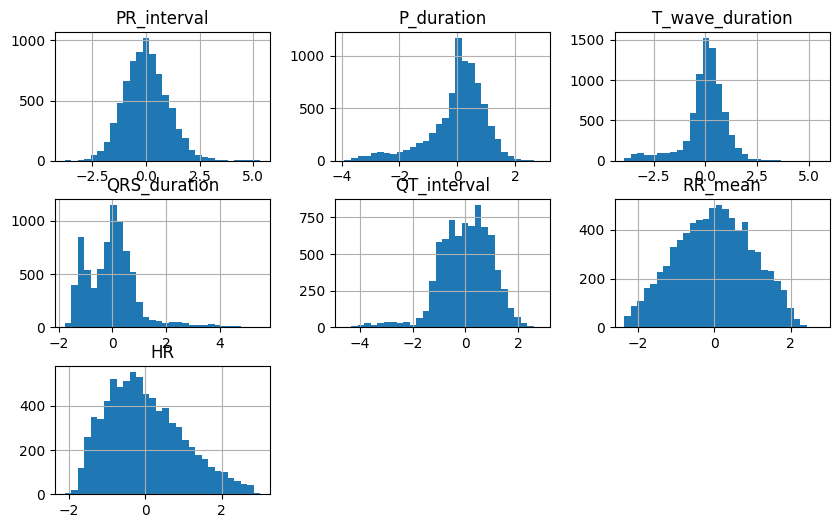

In [599]:
features_duration_scl.hist(figsize=(10, 6), bins=30)

In [600]:
features_amplitude_df = data_clean.loc[: ,['P_amplitude', 'R_amplitude', 'S_depth', 'T_amplitude', 'T_area', 'T_asymmetry']]
features_amplitude_df.describe()

,P_amplitude,R_amplitude,S_depth,T_amplitude,T_area,T_asymmetry
count,7755.000000,7755.000000,7755.000000,7755.000000,7755.000000,7755.000000
mean,0.044491,0.502437,-0.136474,0.136675,0.009920,1.033279
std,0.039907,0.224866,0.086231,0.071551,0.006335,0.299407
min,-0.099241,-0.109966,-0.876584,-0.086663,-0.007053,-2.232220
25%,0.017465,0.341645,-0.176127,0.089741,0.005528,0.910567
50%,0.044042,0.476511,-0.111339,0.131322,0.009455,1.042937
75%,0.070355,0.637618,-0.076397,0.180408,0.013834,1.167150
max,0.205331,1.769894,0.065604,0.533481,0.044996,7.768189


array([[<Axes: title={'center': 'P_amplitude'}>,
        <Axes: title={'center': 'R_amplitude'}>],
       [<Axes: title={'center': 'S_depth'}>,
        <Axes: title={'center': 'T_amplitude'}>],
       [<Axes: title={'center': 'T_area'}>,
        <Axes: title={'center': 'T_asymmetry'}>]], dtype=object)

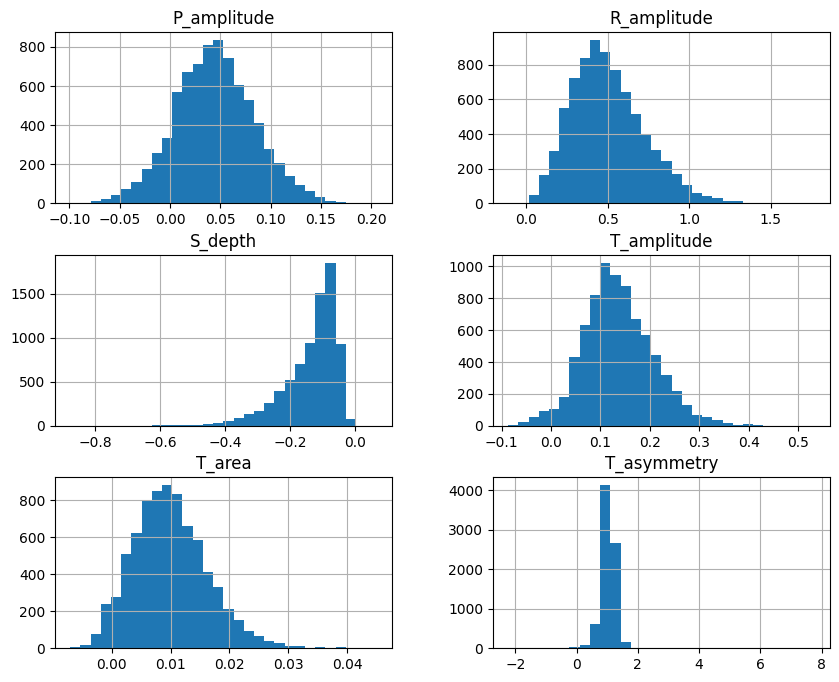

In [601]:
features_amplitude_df.hist(figsize=(10, 8), bins=30)

In [602]:
# T_asymmetry tiene una distribución muy sesgada, por lo que se puede aplicar winsorización para limitar los valores extremos
from scipy.stats.mstats import winsorize

winsorize(features_amplitude_df['T_asymmetry'], limits=[0.01, 0.01],inplace=True)
winsorize(X_test['T_asymmetry'], limits=[0.01, 0.01],inplace=True)

masked_array(data=[1.16538199, 1.06432864, 1.04703491, ..., 0.58070008,
                   0.94189272, 1.2398643 ],
             mask=False,
       fill_value=1e+20)

In [603]:
rb_scaler = RobustScaler(
    quantile_range=(10, 90)
)

features_amplitude_scl = rb_scaler.fit_transform(features_amplitude_df)
features_amplitude_scl_df = pd.DataFrame(features_amplitude_scl, columns=features_amplitude_df.columns)

array([[<Axes: title={'center': 'P_amplitude'}>,
        <Axes: title={'center': 'R_amplitude'}>],
       [<Axes: title={'center': 'S_depth'}>,
        <Axes: title={'center': 'T_amplitude'}>],
       [<Axes: title={'center': 'T_area'}>,
        <Axes: title={'center': 'T_asymmetry'}>]], dtype=object)

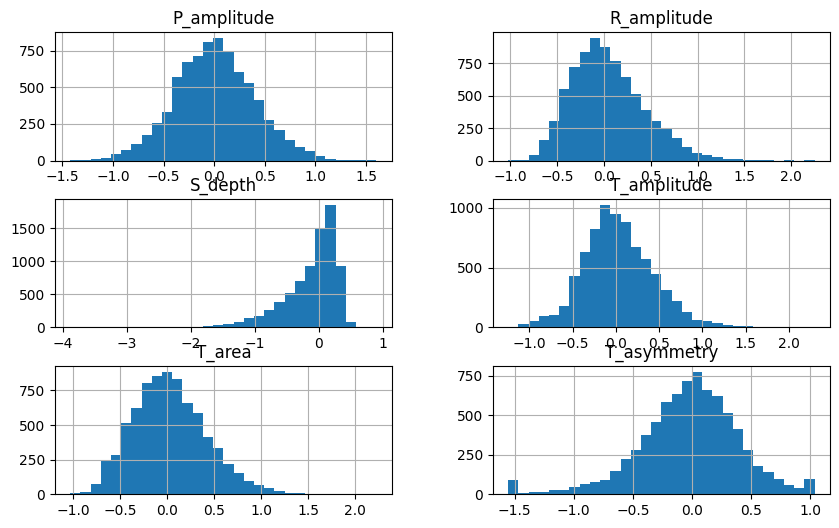

In [604]:
features_amplitude_scl_df.hist(figsize=(10, 6), bins=30)

In [605]:
features_amplitude_scl_df.describe()

,P_amplitude,R_amplitude,S_depth,T_amplitude,T_area,T_asymmetry
count,7755.000000,7755.000000,7755.000000,7755.000000,7755.000000,7755.000000
mean,0.004463,0.045038,-0.127543,0.030561,0.029084,-0.026712
std,0.396565,0.390636,0.437558,0.408538,0.396567,0.430365
min,-1.423840,-1.018824,-3.883047,-1.244634,-1.033443,-1.554603
25%,-0.264100,-0.234288,-0.328751,-0.237416,-0.245881,-0.259980
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.261479,0.279875,0.177303,0.280268,0.274135,0.243962
max,1.602756,2.246861,0.897853,2.296217,2.224923,1.038032


In [606]:
# Construir nuevo DF
features_final_df = pd.concat([features_duration_scl, features_amplitude_scl_df], axis=1)
features_final_df.head()

,PR_interval,P_duration,T_wave_duration,QRS_duration,QT_interval,RR_mean,HR,P_amplitude,R_amplitude,S_depth,T_amplitude,T_area,T_asymmetry
0,-1.017666,-0.162090,0.392804,0.220587,0.542081,-0.146567,0.030065,0.136831,-0.372874,-1.025402,0.198702,0.314503,0.038553
1,-0.608303,-0.162090,-0.898620,0.240210,0.201884,-1.765657,2.007346,0.827330,-0.114968,-0.078666,-0.366669,-0.372745,-0.704746
2,-0.915325,-0.162090,-0.155073,0.318702,0.485382,0.751873,-0.768801,0.551814,-0.064760,-0.223733,0.279139,0.215725,-0.132970
3,-0.403622,0.488283,-0.076805,0.102849,0.258583,0.985185,-1.026640,-0.357681,0.122865,-0.359748,1.112998,1.060655,0.574724
4,0.824466,1.247052,-0.311609,-1.074530,-1.026608,0.601360,-0.686700,-0.010972,0.528436,0.109990,-0.161269,-0.201757,-0.099237


array([[<Axes: title={'center': 'PR_interval'}>,
        <Axes: title={'center': 'P_duration'}>,
        <Axes: title={'center': 'T_wave_duration'}>,
        <Axes: title={'center': 'QRS_duration'}>],
       [<Axes: title={'center': 'QT_interval'}>,
        <Axes: title={'center': 'RR_mean'}>,
        <Axes: title={'center': 'HR'}>,
        <Axes: title={'center': 'P_amplitude'}>],
       [<Axes: title={'center': 'R_amplitude'}>,
        <Axes: title={'center': 'S_depth'}>,
        <Axes: title={'center': 'T_amplitude'}>,
        <Axes: title={'center': 'T_area'}>],
       [<Axes: title={'center': 'T_asymmetry'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

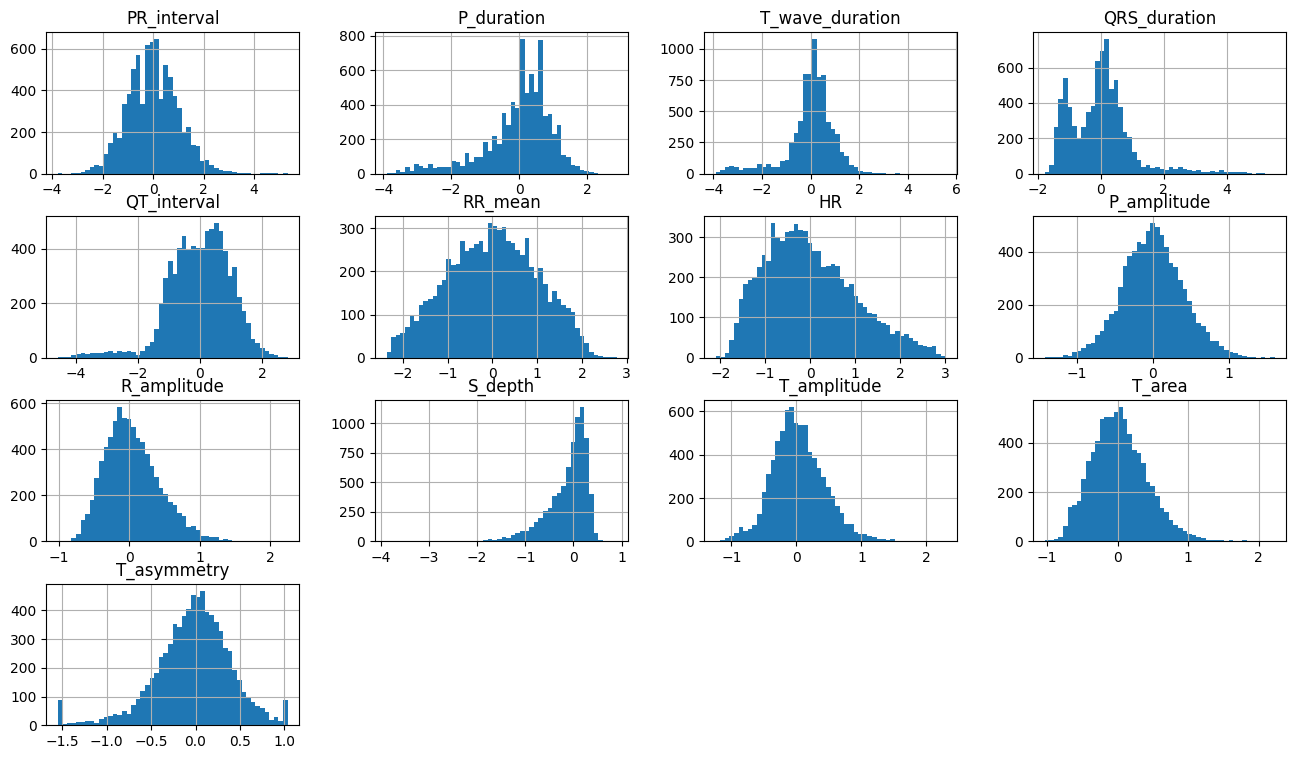

In [607]:
# Plotear dist de frecuencias
features_final_df.hist(
    figsize=(16, 9),
    bins=50,
)

In [608]:
features_final_df.describe()

,PR_interval,P_duration,T_wave_duration,QRS_duration,QT_interval,RR_mean,HR,P_amplitude,R_amplitude,S_depth,T_amplitude,T_area,T_asymmetry
count,7.755000e+03,7.755000e+03,7.755000e+03,7.755000e+03,7.755000e+03,7.755000e+03,7.755000e+03,7755.000000,7755.000000,7755.000000,7755.000000,7755.000000,7755.000000
mean,-6.175446e-16,3.243483e-16,-5.277532e-16,1.209434e-16,7.329906e-18,1.280901e-15,3.582491e-16,0.004463,0.045038,-0.127543,0.030561,0.029084,-0.026712
std,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,0.396565,0.390636,0.437558,0.408538,0.396567,0.430365
min,-3.780863e+00,-3.901736e+00,-3.911942e+00,-1.780957e+00,-4.579782e+00,-2.362850e+00,-2.104146e+00,-1.423840,-1.018824,-3.883047,-1.244634,-1.033443,-1.554603
25%,-7.106439e-01,-3.788812e-01,-3.116090e-01,-7.409390e-01,-6.297104e-01,-7.315958e-01,-7.691553e-01,-0.264100,-0.234288,-0.328751,-0.237416,-0.245881,-0.259980
50%,5.740578e-03,1.630965e-01,1.188656e-01,-1.488867e-02,6.958465e-02,1.841715e-02,-1.364400e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.197844e-01,6.508764e-01,5.493401e-01,4.168169e-01,7.121801e-01,7.411224e-01,6.436866e-01,0.261479,0.279875,0.177303,0.280268,0.274135,0.243962
max,5.327454e+00,2.872985e+00,5.558499e+00,5.518792e+00,2.828965e+00,2.775497e+00,3.015858e+00,1.602756,2.246861,0.897853,2.296217,2.224923,1.038032


In [609]:
col_dur = ['PR_interval', 'P_duration', 'T_wave_duration', 'QRS_duration', 'QT_interval', 'RR_mean', 'HR']
col_amp = ['P_amplitude', 'R_amplitude', 'S_depth', 'T_amplitude', 'T_area', 'T_asymmetry']
col_wins = ['T_asymmetry']

X_train.iloc[:, 1:] = imputer.transform(X_train.iloc[:, 1:])
X_test.iloc[:, 1:] = imputer.transform(X_test.iloc[:, 1:])

X_train.loc[:, col_amp] = rb_scaler.transform(X_train.loc[:, col_amp])
X_test.loc[:, col_amp] = rb_scaler.transform(X_test.loc[:, col_amp])

X_train.loc[:, col_dur] = scaler_std.transform(X_train.loc[:, col_dur])
X_test.loc[:, col_dur] = scaler_std.transform(X_test.loc[:, col_dur])

In [610]:
y_train = pd.DataFrame(y_train)
y_train.iloc[:, -1] = y_train.iloc[:, -1].map({'M': 1, 'F': 0})


In [611]:
y_train

,Sex
1559,0
2935,0
4387,1
9534,1
2291,0
...,...
5734,1
5191,0
5390,1
860,0


In [612]:
y_test = y_test.map({'M':1,'F':0})
y_test

2456    1
8285    1
1550    1
4900    1
39      0
       ..
4081    1
6778    0
4220    0
3898    0
5939    0
Name: Sex, Length: 1939, dtype: int64

In [536]:
print(X_train.dtypes)
print(y_train.dtypes)

PR_interval        float64
P_duration         float64
P_amplitude        float64
R_amplitude        float64
S_depth            float64
T_amplitude        float64
T_wave_duration    float64
T_area             float64
T_asymmetry        float64
QRS_duration       float64
QT_interval        float64
HR                 float64
RR_mean            float64
RR_std             float64
dtype: object
Sex    object
dtype: object


In [613]:
X_train.to_csv('../data/training_sets/X_train.csv')
X_test.to_csv('../data/training_sets/X_test.csv')

y_train.to_csv('../data/training_sets/y_train.csv')
y_test.to_csv('../data/training_sets/y_test.csv')